In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import  LinearRegression
import matplotlib.ticker as ticker

In [3]:
np.random.seed(42)

house_size = np.random.randint(500, 3500, size=100)
house_price = house_size * 300 + np.random.randint(20000, 50000, size=100)
#create a dataframe
df = pd.DataFrame({
    'Size_sqft': house_size,
    'Price': house_price
})

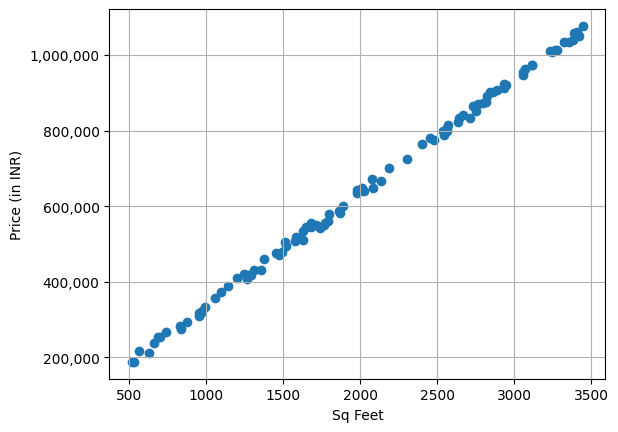

In [4]:
plt.scatter(df['Size_sqft'], df['Price'])
plt.grid()


"""
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}') this or that
)
"""
plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
)

plt.xlabel('Sq Feet')
plt.ylabel('Price (in INR)')

plt.show()

In [5]:
def stline(x, m, b):
    y = (m * x) + b

    print('Slope (m)    :', m)
    print('intercept (y):', b)
    print('Size (x)     :', x)

    print('\ny = (m * x) + b')
    print('\ny =', m, '*', x, '+', b)

    print('\nPredicted Price :', y)

In [6]:
stline(x=1000,m=300,b=50000)

Slope (m)    : 300
intercept (y): 50000
Size (x)     : 1000

y = (m * x) + b

y = 300 * 1000 + 50000

Predicted Price : 350000


In [7]:
# Separate features (X) and target (y)

X = df[['Size_sqft']]
y = df['Price']
X.head()
y.head()
df.head()

,Size_sqft,Price
0,1360,430027
1,1794,560895
2,1630,535071
3,1595,513922
4,2138,666658


In [8]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [15]:
m = model.coef_[0]
b = model.intercept_

print('Slope (m):', m)
print('Intercept (b):', b)
y_pred = model.predict(X)

Slope (m): 300.470892704462
Intercept (b): 35072.15953140822


In [10]:
house_size_input = 1000

predicted_price = model.predict([[house_size_input]])

print(
    f"Predicted price for a {house_size_input} sqft house: "
    f"{predicted_price[0]:,.2f}"
)

Predicted price for a 1000 sqft house: 335,543.05


c:\Users\madha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


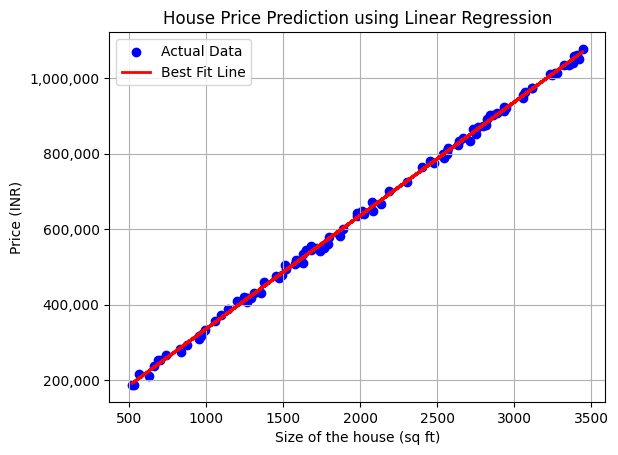

In [11]:
plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(
    X,
    y_pred,
    color='red',
    linewidth=2,
    label='Best Fit Line'
)

plt.xlabel('Size of the house (sq ft)')
plt.ylabel('Price (INR)')

plt.gca().yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f'{int(x):,}')
)

plt.grid()

plt.title('House Price Prediction using Linear Regression')

plt.legend()

plt.show()

In [12]:
df[(df['Size_sqft'] > 1000) & (df['Size_sqft'] < 1200)]

,Size_sqft,Price
37,1062,356012
42,1146,389246
48,1100,374105


In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [17]:
lr = LinearRegression()
x = df[['Size_sqft']]
y = df['Price']
df.head()

,Size_sqft,Price
0,1360,430027
1,1794,560895
2,1630,535071
3,1595,513922
4,2138,666658


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.15,
    random_state=42

)

In [19]:
# ==========================================
# 15. TRAIN MODEL
# ==========================================

lr.fit(x_train, y_train)


# ==========================================
# 16. PREDICT TEST DATA
# ==========================================

lr_preds = lr.predict(x_test)


# ==========================================
# 17. ACTUAL VS PREDICTED
# ==========================================

results = pd.DataFrame({
    'Actuals': y_test,
    'Predictions': lr_preds
})

results['Difference'] = np.abs(
    results['Actuals'] - results['Predictions']
)

print(results)


# ==========================================
# 18. MSE
# ==========================================

lr_mse = mean_squared_error(
    y_test,
    lr_preds
)

print('MSE:', lr_mse)


# ==========================================
# 19. RMSE
# ==========================================

lr_rmse = np.sqrt(lr_mse)

print('RMSE:', lr_rmse)


# ==========================================
# 20. R2 SCORE
# ==========================================

lr_r2 = r2_score(
    y_test,
    lr_preds
)

print('R2 Score:', lr_r2)

    Actuals   Predictions    Difference
83   902623  8.894676e+05  13155.354646
53  1034447  1.034009e+06    437.913251
70   410455  3.963439e+05  14111.066349
45   834406  8.507029e+05  16296.892880
44  1057272  1.053241e+06   4030.787993
39   550602  5.661275e+05  15525.539448
22   554374  5.411859e+05  13188.122997
80   317752  3.221200e+05   4367.950232
10   823166  8.269632e+05   3797.238264
0    430027  4.438232e+05  13796.242883
18   912967  9.165128e+05   3545.821499
30   947162  9.540756e+05   6913.566144
73   671590  6.598842e+05  11705.849918
33   470610  4.783810e+05   7770.967957
90   416947  4.146746e+05   2272.446962
MSE: 103731046.8554638
RMSE: 10184.843977963717
R2 Score: 0.9982679017739197
